In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.stats as stats

import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 12,
    })
from matplotlib.colors import Normalize
import corner

from plot_eos_inference import (load_posterior, 
                                plot_mr, plot_ml, 
                                plot_pressure, 
                                plot_pop, 
                                corner_plot, 
                                get_quantiles, 
                                r14_confidence_interval, 
                                l14_confidence_interval, 
                                mtov_confidence_interval, 
                                plot_mr_nofill, plot_pop_nofill,
                                plot_ml_relative)

# load EOS
m_eos, r_eos, l_eos = np.loadtxt("../../eos/RMF3_MRL.dat", unpack=True)
mtov = m_eos.max()
n_eos, p_eos = np.loadtxt("../../eos/RMF3_cold_beta_lamb.d", unpack=True, usecols=[1,3])

latex_labels={"mu_1": "$\\mu_1$", "mu_2": "$\\mu_2$", "sigma_1": "$\\sigma_1$", "sigma_2": "$\\sigma_2$", "alpha": "$\\alpha$", "m_min": "$m_{\\rm{min}}$", "m_max": "$m_{\\rm{max}}$" }
fontsize=14

def pressure_confidence_interval(posterior):
    x = np.geomspace(0.5, 10, 100) # densities 
    x, quantiles, _ = get_quantiles(x, posterior["densities_EOS"] / 0.16, posterior["pressures_EOS"], posterior["weights"])

    lower = np.interp(3, x, quantiles[:, 0])
    median = np.interp(3, x, quantiles[:, 2])
    upper = np.interp(3, x, quantiles[:, 4])
    plus = upper-median
    minus = median-lower

    return f"{{{median:.0f}}}^{{+{plus:.0f}}}_{{-{minus:.0f}}}"

def confidence_interval(posterior, key):

    lower, median, upper = np.quantile(posterior[key], [0.025, 0.5, 0.975], weights=posterior["weights"], method="inverted_cdf")
    minus = median - lower
    plus = upper - median

    return f"{{{median:.2f}}}_{{-{minus:.2f}}}^{{+{plus:.2f}}}"

## narrow ETL

In [2]:
directory = Path("../narrow_ETL")

posterior_gw = load_posterior(directory / "eos_inference_gw" / "outdir" / "results.h5")
posterior_mm = load_posterior(directory / "eos_inference_mm" / "outdir" / "results.h5")
posterior_mm_without_em = load_posterior(directory / "eos_inference_mm_without_em" / "outdir" / "results.h5")


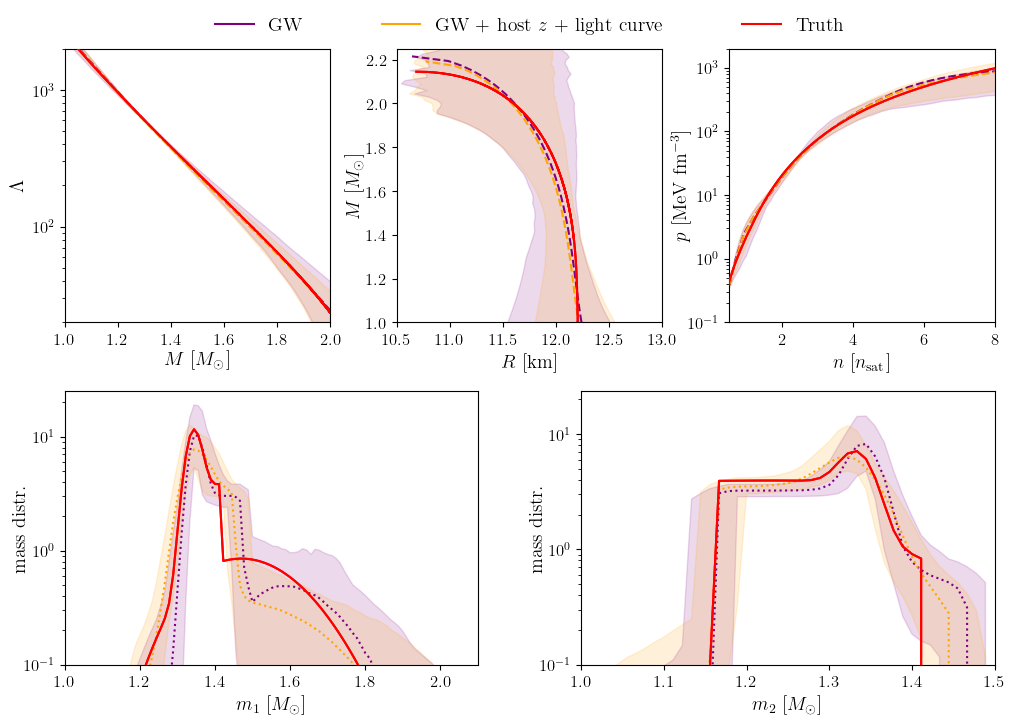

In [3]:
fig = plt.figure(figsize=(12, 8))

outer = fig.add_gridspec(2, 1, hspace=0.25)

# upper: 3 side to side panels
upper = outer[0].subgridspec(1, 3, wspace=0.25)

# lower: 2 side to side panels
lower = outer[1].subgridspec(1, 2, wspace=0.25)

ax_ml= fig.add_subplot(upper[0])
ax_mr = fig.add_subplot(upper[1])
ax_pressure = fig.add_subplot(upper[2])
ax_pop1 = fig.add_subplot(lower[0])
ax_pop2 = fig.add_subplot(lower[1])

plot_ml(ax_ml, posterior_gw, color="purple")
plot_ml(ax_ml, posterior_mm, color="orange")

plot_mr(ax_mr, posterior_gw, color="purple", plot_bestfit=True)
plot_mr(ax_mr, posterior_mm, color="orange", plot_bestfit=True)

plot_pressure(ax_pressure, posterior_gw, color="purple", plot_bestfit=True)
plot_pressure(ax_pressure, posterior_mm, color="orange",)

plot_pop([ax_pop1, ax_pop2], posterior_gw, color="purple")
plot_pop([ax_pop1, ax_pop2], posterior_mm, color="orange")

ax_pop2.set_xlim((1.0, 1.5))

lc1 = plt.plot([], [], color="purple")[0]
lc2 = plt.plot([], [], color="orange")[0]
lc3 = plt.plot([], [], color="red")[0]
ax_mr.legend(
    [lc1, lc2, lc3], 
    ["GW", "GW + host $z$ + light curve", "Truth"], 
    fontsize=14,
    framealpha=1.,
    fancybox=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.18),
    frameon=False, ncol=3,
    columnspacing=4
)

fig.savefig(
    "../../figures/eos_inference_narrow_ETL.pdf",
    dpi=250,
    bbox_inches="tight"
)

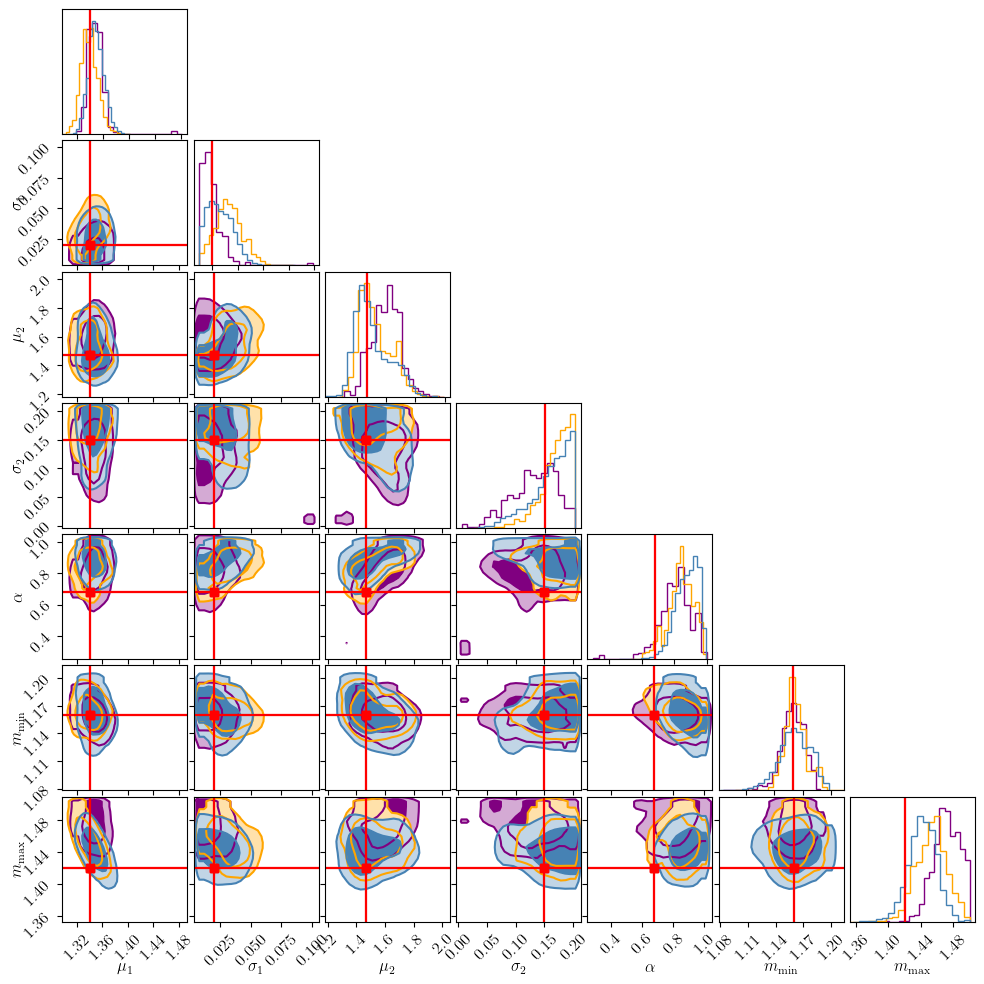

In [4]:
fig = corner_plot(posterior_gw, ["mu_1", "sigma_1", "mu_2", "sigma_2", "alpha", "m_min", "m_max"])
fig = corner_plot(posterior_mm, ["mu_1", "sigma_1", "mu_2", "sigma_2", "alpha", "m_min", "m_max"], fig, color="orange")
fig = corner_plot(posterior_mm_without_em, ["mu_1", "sigma_1", "mu_2", "sigma_2", "alpha", "m_min", "m_max"], fig, color="steelblue")

In [7]:
posterior_mm["weights"] = np.full(7000, 1/7000)
posterior_gw["weights"] = np.full(7000, 1/7000)


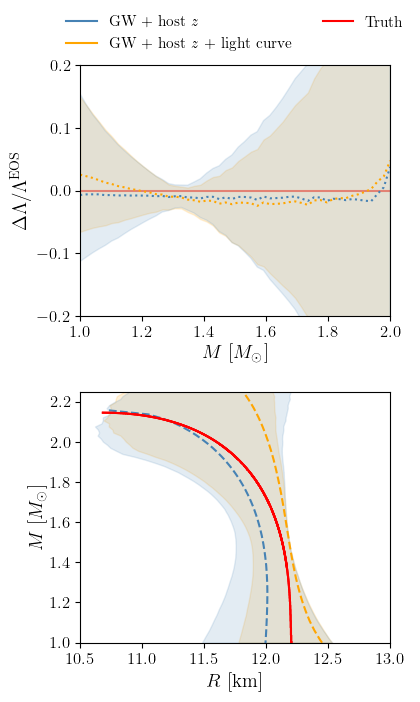

In [14]:
fig, ax = plt.subplots(2, 1, figsize=(4, 10*0.75))
fig.subplots_adjust(hspace=0.3)

plot_ml_relative(ax[0], posterior_mm, color="orange")
plot_ml_relative(ax[0], posterior_mm_without_em, color="steelblue")

ax[0].set_xlim((1, 2))


plot_mr(ax[1], posterior_mm, color="orange")
plot_mr(ax[1], posterior_mm_without_em, color="steelblue")

lc1 = plt.plot([], [], color="steelblue")[0]
lc2 = plt.plot([], [], color="orange")[0]
lc3 = plt.plot([], [], color="red")[0]

ax[0].legend(
    [lc1, lc2, lc3], 
    ["GW + host $z$", "GW + host $z$ + light curve", "Truth"], 
    fontsize=11,
    framealpha=1.,
    fancybox=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.25),
    frameon=False,
    ncol=2
)

fig.savefig("../../figures/eos_inference_narrow_ETL_mm_vs_gw.pdf", dpi=250, bbox_inches="tight")

In [101]:
print(r14_confidence_interval(posterior_gw))
print(r14_confidence_interval(posterior_mm))
print(r14_confidence_interval(posterior_mm_without_em))

{12.08}^{+0.14}_{-0.30}
{12.03}^{+0.23}_{-0.14}
{12.01}^{+0.26}_{-0.48}


In [108]:
print(l14_confidence_interval(posterior_gw))
print(l14_confidence_interval(posterior_mm))
print(l14_confidence_interval(posterior_mm_without_em))


{382}^{+13}_{-13}
{374}^{+13}_{-12}
{378}^{+13}_{-14}


In [121]:
print(confidence_interval(posterior_gw["m_max"], posterior_gw["weights"]))
print(confidence_interval(posterior_mm["m_max"], posterior_mm["weights"]))

{1.47}_{-0.03}^{+0.03}
{1.45}_{-0.04}^{+0.03}


(0.0, 0.5)

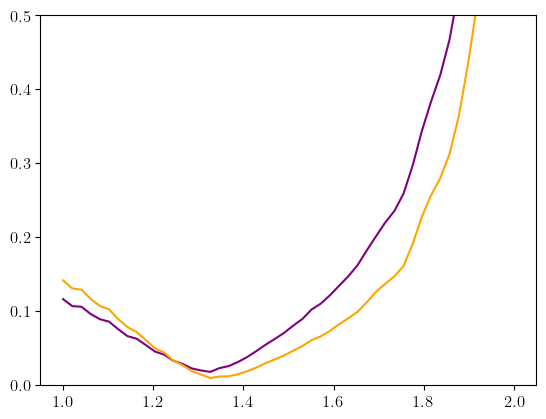

In [5]:
key = "lambdas_EOS"

xs, quantiles_gw, _ = get_quantiles(np.linspace(1, 2, 50), posterior_gw["masses_EOS"], posterior_gw[key], posterior_gw["weights"])
xs, quantiles_mm, _ = get_quantiles(np.linspace(1, 2, 50), posterior_mm["masses_EOS"], posterior_mm[key], posterior_mm["weights"])

plt.plot(xs, (quantiles_gw[:, 2] / quantiles_gw[:, 0] - 1), color="purple")
plt.plot(xs, (quantiles_mm[:, 2] / quantiles_gw[:, 0] - 1), color="orange")

plt.ylim((0, 0.5))

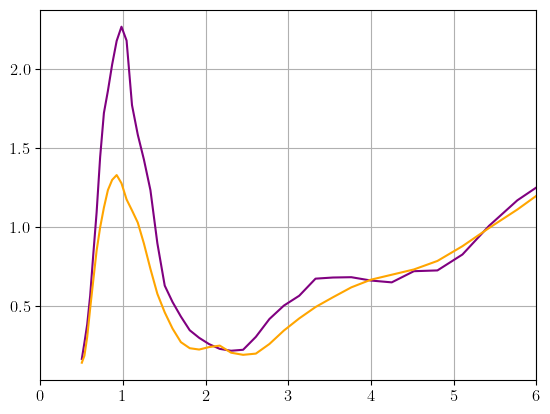

In [6]:
xs, quantiles, _ = get_quantiles(np.geomspace(0.5, 10, 50), posterior_gw["densities_EOS"]/0.16, posterior_gw["pressures_EOS"], posterior_gw["weights"])
xs, quantiles_mm, _ = get_quantiles(np.geomspace(0.5, 10, 50), posterior_mm["densities_EOS"]/0.16, posterior_mm["pressures_EOS"], posterior_mm["weights"])

plt.plot(xs, (quantiles[:, 4] / quantiles[:, 0])-1, color="purple")
plt.plot(xs, (quantiles_mm[:, 4] / quantiles_mm[:, 0])-1, color="orange")
plt.xlim((0, 6))
plt.grid(True)

In [78]:
print(r14_confidence_interval(posterior_gw))
print(r14_confidence_interval(posterior_mm))

{11.94}^{+0.23}_{-0.33}
{12.03}^{+0.23}_{-0.14}


In [79]:
print(l14_confidence_interval(posterior_gw))
print(l14_confidence_interval(posterior_mm))

{385}^{+12}_{-13}
{374}^{+13}_{-12}


In [112]:
print(mtov_confidence_interval(posterior_gw))
print(mtov_confidence_interval(posterior_mm))

{2.11}^{+0.16}_{-0.16}
{2.07}^{+0.23}_{-0.13}


In [118]:
print(pressure_confidence_interval(posterior_gw))
print("(", pressure_confidence_interval(posterior_mm), ")")

{76}^{+25}_{-11}
( {70}^{+21}_{-7} )


/home/koehn1/miniconda3/envs/nmma_x_fiesta/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1601: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


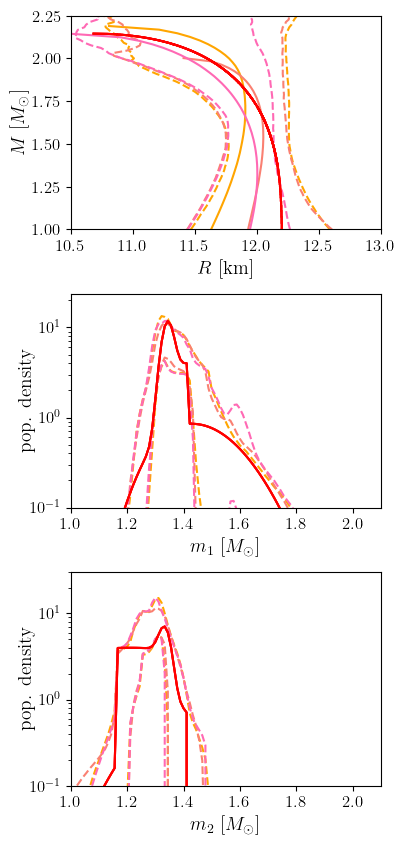

In [5]:
posterior_mm_cheat["weights"] = np.full((7000, ), 1/7000)
posterior_mm["weights"] = np.full((7000, ), 1/7000)
posterior_mm_full['weights'] = np.full((7000, ), 1/7000)

fig, ax = plt.subplots(3, 1, figsize=(4, 10))
fig.subplots_adjust(hspace=0.3)

plot_mr_nofill(ax[0], posterior_mm, color="orange")
plot_mr_nofill(ax[0], posterior_mm_full, color="salmon")
plot_mr_nofill(ax[0], posterior_mm_cheat, color="hotpink")

plot_pop_nofill(ax[1:], posterior_mm, color="orange")
plot_pop_nofill(ax[1:], posterior_mm_full, color="salmon")
plot_pop_nofill(ax[1:], posterior_mm_cheat, color="hotpink")

fig.savefig("../../figures/eos_inference_different_mm.pdf", dpi=250, bbox_inches="tight")


In [ ]:

print(l14_confidence_interval(posterior_mm))
print(l14_confidence_interval(posterior_mm_alt))
print(l14_confidence_interval(posterior_mm_cheat))

{393}^{+14}_{-16}
{394}^{+16}_{-16}
{393}^{+13}_{-14}


/home/koehn1/miniconda3/envs/nmma_x_fiesta/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1601: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


(10.0, 13.0)

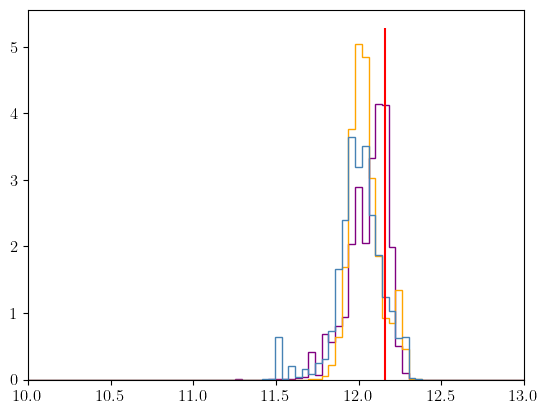

In [123]:
m_x = 1.4

r14_gw = np.array([np.interp(m_x, posterior_gw["masses_EOS"][j], posterior_gw["radii_EOS"][j]) for j in range(7000)])
r14_mm = np.array([np.interp(m_x, posterior_mm["masses_EOS"][j], posterior_mm["radii_EOS"][j]) for j in range(7000)])
r14_mm_without_em = np.array([np.interp(m_x, posterior_mm_without_em["masses_EOS"][j], posterior_mm_without_em["radii_EOS"][j]) for j in range(7000)])


bins = np.linspace(10, 14, 100)
plt.hist(r14_gw, color="purple", density=True, histtype="step", bins=bins, weights=posterior_gw["weights"])
plt.hist(r14_mm, color="orange", density=True, histtype="step", bins=bins, weights=posterior_mm["weights"])
plt.hist(r14_mm_without_em, color="steelblue", density=True, histtype="step", bins=bins, weights=posterior_mm_without_em["weights"])

plt.vlines([np.interp(m_x, m_eos, r_eos)], *plt.gca().get_ylim(), color="red")

plt.xlim(10, 13.0)

(286.9962203887556, 491.2696494387004)

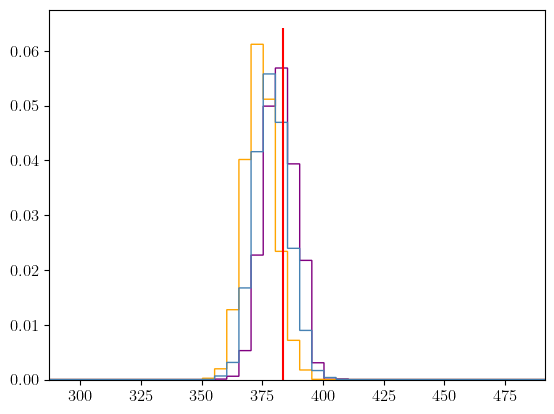

In [122]:
mx = 1.4

l14_gw = np.array([np.interp(mx, posterior_gw["masses_EOS"][j], posterior_gw["lambdas_EOS"][j]) for j in range(7000)])
l14_mm = np.array([np.interp(mx, posterior_mm["masses_EOS"][j], posterior_mm["lambdas_EOS"][j]) for j in range(7000)])
l14_mm_without_em = np.array([np.interp(mx, posterior_mm_without_em["masses_EOS"][j], posterior_mm_without_em["lambdas_EOS"][j]) for j in range(7000)])


bins = np.linspace(0, 5000, 1000)
plt.hist(l14_gw, color="purple", density=True, histtype="step", bins=bins, weights=posterior_gw["weights"])
plt.hist(l14_mm, color="orange", density=True, histtype="step", bins=bins, weights=posterior_mm["weights"])
plt.hist(l14_mm_without_em, color="steelblue", density=True, histtype="step", bins=bins, weights=posterior_mm["weights"])
plt.vlines([np.interp(mx, m_eos, l_eos)], *plt.gca().get_ylim(), color="red")
plt.xlim((l14_gw.min() * 0.8, l14_gw.max()*1.2))


## wide ETL

In [4]:
directory = Path("../wide_ETL")

posterior_gw = load_posterior(directory / "eos_inference_gw" / "outdir" / "results.h5")
posterior_mm = load_posterior(directory / "eos_inference_mm" / "outdir" / "results.h5")



/home/koehn1/miniconda3/envs/nmma_x_fiesta/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1601: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


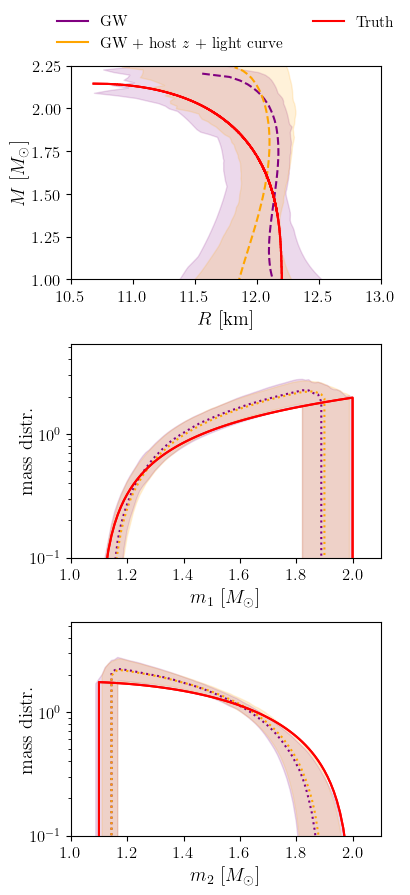

In [ ]:
fig, ax = plt.subplots(3, 1, figsize=(4, 10))
fig.subplots_adjust(hspace=0.3)

plot_mr(ax[0], posterior_gw, color="purple")
plot_mr(ax[0], posterior_mm, color="orange")

plot_pop(ax[1:], posterior_gw, color="purple")
plot_pop(ax[1:], posterior_mm, color="orange")

lc1 = plt.plot([], [], color="purple")[0]
lc2 = plt.plot([], [], color="orange")[0]
lc3 = plt.plot([], [], color="red")[0]

ax[0].legend(
    [lc1, lc2, lc3], 
    ["GW", "GW + host $z$ + light curve", "Truth"], 
    fontsize=11,
    framealpha=1.,
    fancybox=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.3),
    frameon=False,
    ncol=2
)

fig.savefig("../../figures/eos_inference_wide_ETL.pdf", dpi=250, bbox_inches="tight")

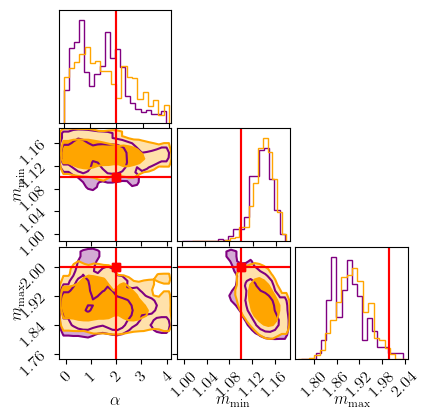

In [13]:
fig = corner_plot(posterior_gw, ["alpha", "m_min", "m_max"])
fig = corner_plot(posterior_mm, ["alpha", "m_min", "m_max"], fig, color="orange")

In [6]:
print(l14_confidence_interval(posterior_gw))
print(l14_confidence_interval(posterior_mm))

{399}^{+19}_{-26}
{399}^{+21}_{-20}


/home/koehn1/miniconda3/envs/nmma_x_fiesta/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1601: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


In [7]:
print(r14_confidence_interval(posterior_gw))
print(r14_confidence_interval(posterior_mm))

{12.00}^{+0.26}_{-0.31}
{11.99}^{+0.19}_{-0.18}


In [8]:
print(pressure_confidence_interval(posterior_gw))
print(pressure_confidence_interval(posterior_mm))

{85}^{+26}_{-14}
{87}^{+23}_{-13}


(11.5, 13.0)

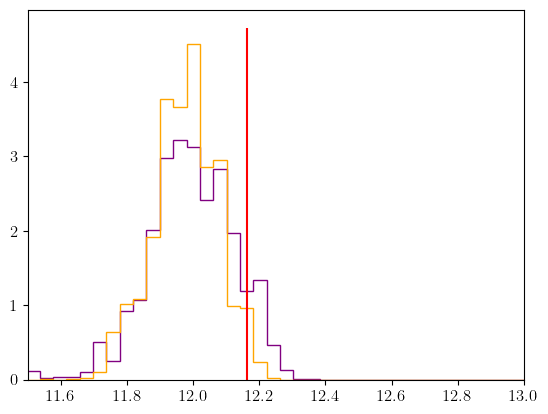

In [24]:
r14_gw = np.array([np.interp(1.4, posterior_gw["masses_EOS"][j], posterior_gw["radii_EOS"][j]) for j in range(7000)])
r14_mm = np.array([np.interp(1.4, posterior_mm["masses_EOS"][j], posterior_mm["radii_EOS"][j]) for j in range(7000)])

bins = np.linspace(10, 14, 100)
plt.hist(r14_gw, color="purple", density=True, histtype="step", bins=bins, weights=posterior_gw["weights"])
plt.hist(r14_mm, color="orange", density=True, histtype="step", bins=bins, weights=posterior_mm["weights"])
plt.vlines([np.interp(1.4, m_eos, r_eos)], *plt.gca().get_ylim(), color="red")
plt.xlim(11.5, 13.0)

(49.57298078213025, 135.4117495243438)

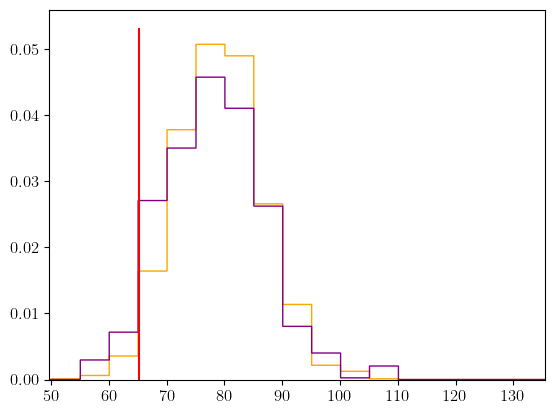

In [17]:
mx = 1.8

l14_mm  = np.array([np.interp(mx, posterior_mm["masses_EOS"][j], posterior_mm["lambdas_EOS"][j]) for j in range(7000)])
l14_gw = np.array([np.interp(mx, posterior_gw["masses_EOS"][j], posterior_gw["lambdas_EOS"][j]) for j in range(7000)])


bins = np.linspace(0, 5000, 1000)
plt.hist(l14_mm, color="orange", density=True, histtype="step", bins=bins, weights=posterior_mm["weights"])
plt.hist(l14_gw, color="purple", density=True, histtype="step", bins=bins, weights=posterior_gw["weights"])


plt.vlines([np.interp(mx, m_eos, l_eos)], *plt.gca().get_ylim(), color="red")
plt.xlim((l14_gw.min()*0.9, l14_gw.max()*1.1))

In [18]:
print(confidence_interval(posterior_gw["alpha"], posterior_gw["weights"]))
print(confidence_interval(posterior_mm["alpha"], posterior_mm["weights"]))

{1.42}_{-1.25}^{+1.91}
{1.88}_{-1.55}^{+1.99}


# Narrow ETT

In [9]:
directory = Path("../narrow_ETT")

posterior_gw = load_posterior(directory / "eos_inference_gw" / "outdir" / "results.h5")
posterior_mm = load_posterior(directory / "eos_inference_mm" / "outdir" / "results.h5")


/home/koehn1/miniconda3/envs/nmma_x_fiesta/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1601: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


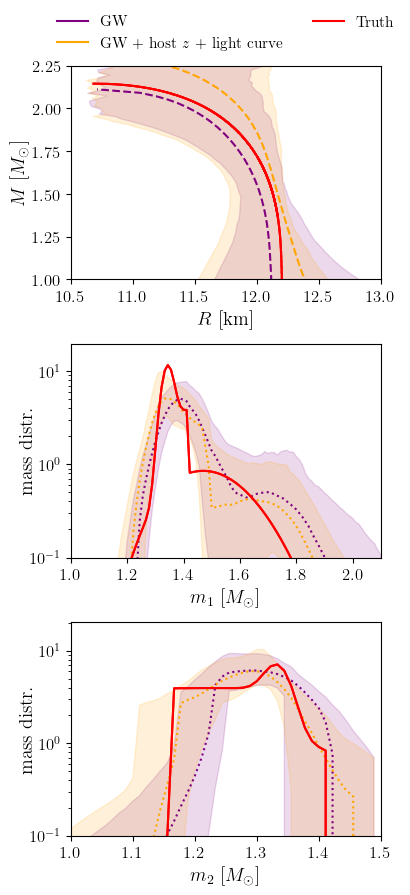

In [5]:
fig, ax = plt.subplots(3, 1, figsize=(4, 10))
fig.subplots_adjust(hspace=0.3)


plot_mr(ax[0], posterior_gw, color="purple")
plot_mr(ax[0], posterior_mm, color="orange")

plot_pop(ax[1:], posterior_gw, color="purple")
plot_pop(ax[1:], posterior_mm, color="orange")
ax[2].set_xlim((1.0, 1.5))

lc1 = plt.plot([], [], color="purple")[0]
lc2 = plt.plot([], [], color="orange")[0]
lc3 = plt.plot([], [], color="red")[0]

ax[0].legend(
    [lc1, lc2, lc3], 
    ["GW", "GW + host $z$ + light curve", "Truth"], 
    fontsize=11,
    framealpha=1.,
    fancybox=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.3),
    frameon=False,
    ncol=2
)

fig.savefig("../../figures/eos_inference_narrow_ETT.pdf", dpi=250, bbox_inches="tight")

In [77]:
print(l14_confidence_interval(posterior_gw))
print(l14_confidence_interval(posterior_mm))

{381}^{+18}_{-15}
{380}^{+16}_{-17}


In [78]:
print(r14_confidence_interval(posterior_gw))
print(r14_confidence_interval(posterior_mm))

{12.06}^{+0.26}_{-0.20}
{12.03}^{+0.21}_{-0.26}


(275.2066964003872, 493.0233615085795)

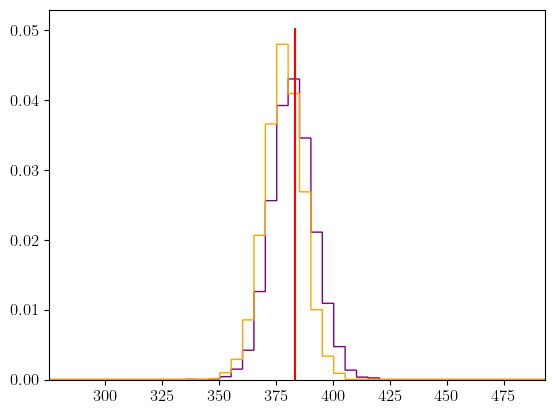

In [51]:
mx = 1.4

l14_gw = np.array([np.interp(mx, posterior_gw["masses_EOS"][j], posterior_gw["lambdas_EOS"][j]) for j in range(7000)])
l14_mm = np.array([np.interp(mx, posterior_mm["masses_EOS"][j], posterior_mm["lambdas_EOS"][j]) for j in range(7000)])


bins = np.linspace(0, 5000, 1000)
plt.hist(l14_gw, color="purple", density=True, histtype="step", bins=bins)
plt.hist(l14_mm, color="orange", density=True, histtype="step", bins=bins)

plt.vlines([np.interp(mx, m_eos, l_eos)], *plt.gca().get_ylim(), color="red")
plt.xlim((l14_mm.min()*0.8, l14_mm.max()*1.2))

(10.0, 13.0)

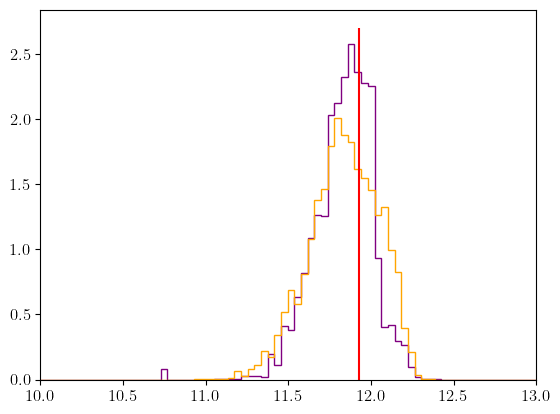

In [86]:
m_x = 1.8

r14_gw = np.array([np.interp(m_x, posterior_gw["masses_EOS"][j], posterior_gw["radii_EOS"][j]) for j in range(7000)])
r14_mm = np.array([np.interp(m_x, posterior_mm["masses_EOS"][j], posterior_mm["radii_EOS"][j]) for j in range(7000)])


bins = np.linspace(10, 14, 100)
plt.hist(r14_gw, color="purple", density=True, histtype="step", bins=bins, weights=posterior_gw["weights"])
plt.hist(r14_mm, color="orange", density=True, histtype="step", bins=bins, weights=posterior_mm["weights"])

plt.vlines([np.interp(m_x, m_eos, r_eos)], *plt.gca().get_ylim(), color="red")

plt.xlim(10, 13.0)

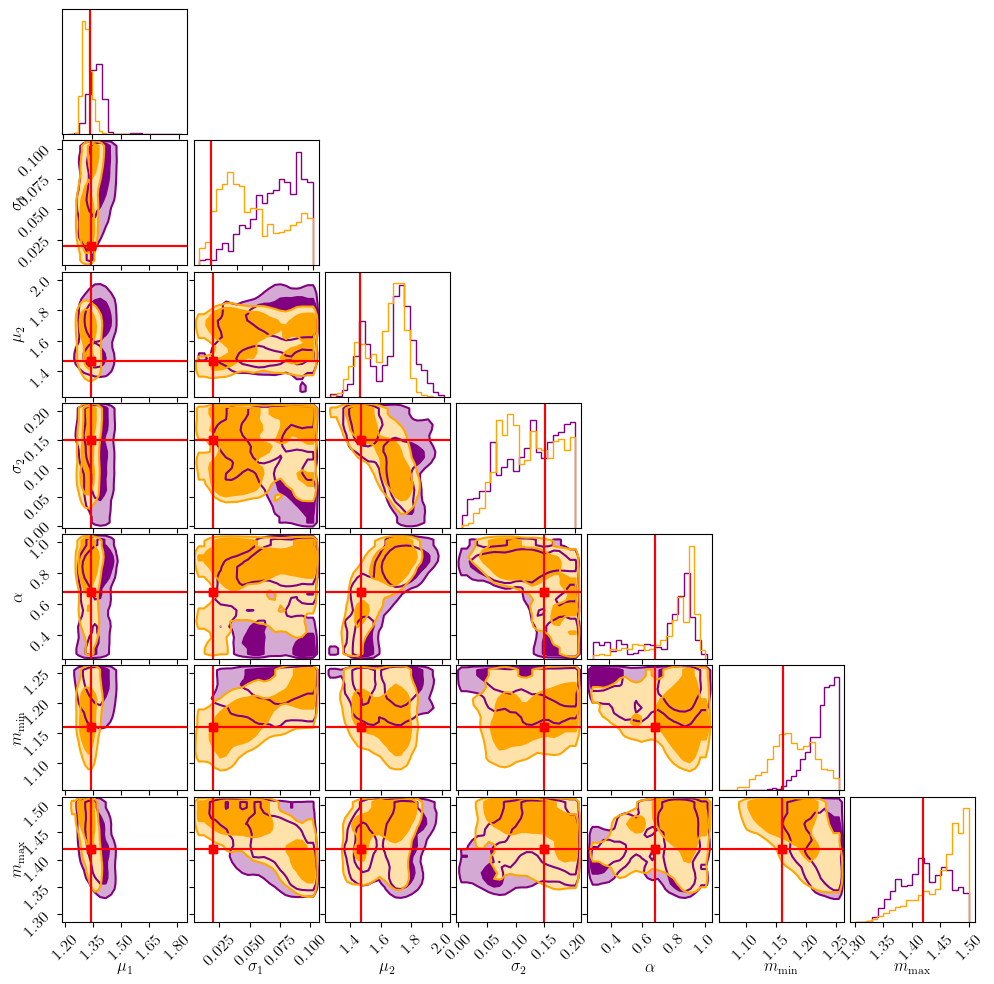

In [6]:
fig = corner_plot(posterior_gw, ["mu_1", "sigma_1", "mu_2", "sigma_2", "alpha", "m_min", "m_max"])
fig = corner_plot(posterior_mm, ["mu_1", "sigma_1", "mu_2", "sigma_2", "alpha", "m_min", "m_max"], fig, color="orange")

## wide ETT

In [16]:
directory = Path("../wide_ETT")

posterior_gw = load_posterior(directory / "eos_inference_gw" / "outdir" / "results.h5")
posterior_mm = load_posterior(directory / "eos_inference_mm" / "outdir" / "results.h5")
posterior_nohighSNR = load_posterior(directory / "eos_inference_mm_nohighSNR" / "outdir" / "results.h5")


/home/koehn1/miniconda3/envs/nmma_x_fiesta/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1601: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


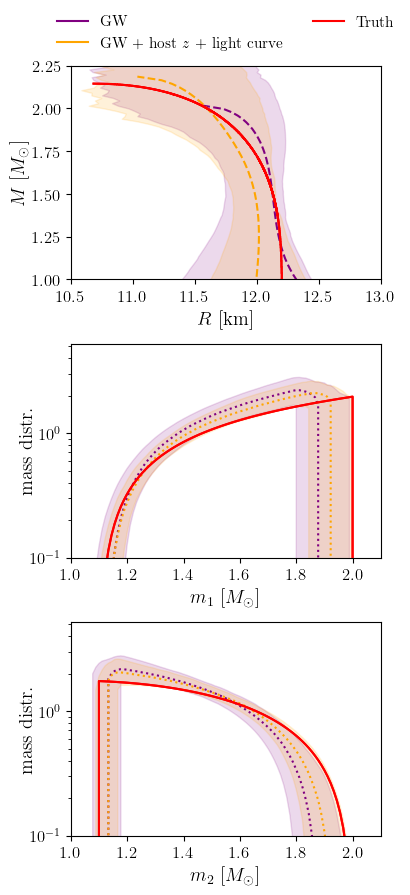

In [17]:
fig, ax = plt.subplots(3, 1, figsize=(4, 10))
fig.subplots_adjust(hspace=0.3)

plot_mr(ax[0], posterior_gw, color="purple")
plot_mr(ax[0], posterior_mm, color="orange")

plot_pop(ax[1:], posterior_gw, color="purple")
plot_pop(ax[1:], posterior_mm, color="orange")
#plot_pop(ax[1:], posterior_nohighSNR, color="pink")


lc1 = plt.plot([], [], color="purple")[0]
lc2 = plt.plot([], [], color="orange")[0]
lc3 = plt.plot([], [], color="red")[0]

ax[0].legend(
    [lc1, lc2, lc3], 
    ["GW", "GW + host $z$ + light curve", "Truth"], 
    fontsize=11,
    framealpha=1.,
    fancybox=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.3),
    frameon=False,
    ncol=2
)


fig.savefig("../../figures/eos_inference_wide_ETT.pdf", dpi=250, bbox_inches="tight")

(1.0, 2.0)

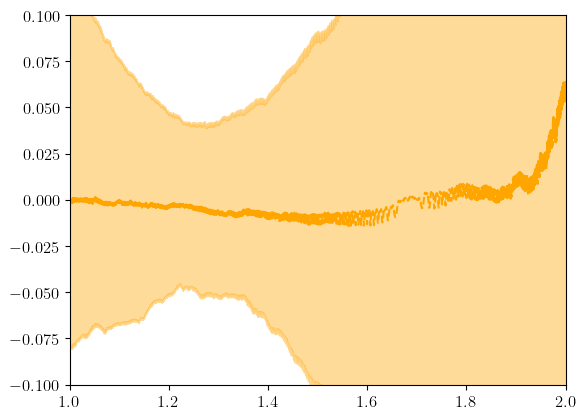

In [4]:
mx = np.linspace(1, 2, 50)

_, quantiles, _ = get_quantiles(m_eos, posterior_mm["masses_EOS"], posterior_mm["lambdas_EOS"], posterior_mm["weights"])

plt.plot(m_eos, quantiles[:, 2]/  l_eos -1, color="orange", linestyle="dashed")
plt.fill_between(m_eos, quantiles[:, 4]/  l_eos -1, quantiles[:, 0] / l_eos- 1, color="orange", alpha=0.4)


plt.ylim(-0.1, 0.1)
plt.xlim(1,2)

In [40]:
print(l14_confidence_interval(posterior_gw))
print(l14_confidence_interval(posterior_mm))
print(l14_confidence_interval(posterior_nohighSNR))

{391}^{+28}_{-30}
{383}^{+23}_{-27}
{387}^{+35}_{-33}


/home/koehn1/miniconda3/envs/nmma_x_fiesta/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1601: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


In [45]:
print(r14_confidence_interval(posterior_gw))
print(r14_confidence_interval(posterior_mm))
print(r14_confidence_interval(posterior_nohighSNR))

{11.99}^{+0.24}_{-0.26}
{11.99}^{+0.16}_{-0.25}
{12.00}^{+0.20}_{-0.22}


In [12]:
print(confidence_interval(posterior_gw["m_max"], posterior_gw["weights"]))
print(confidence_interval(posterior_mm["m_max"], posterior_mm["weights"]))

{1.88}_{-0.07}^{+0.11}
{1.90}_{-0.08}^{+0.11}


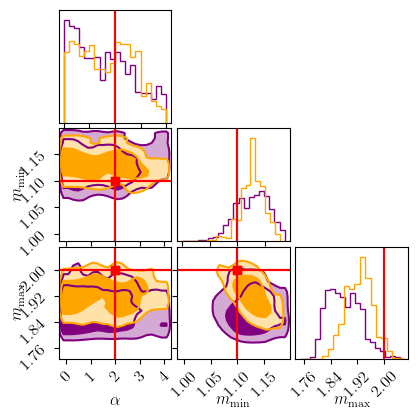

In [11]:
fig = corner_plot(posterior_gw, ["alpha", "m_min", "m_max"])
fig = corner_plot(posterior_mm, ["alpha", "m_min", "m_max"], fig, color="orange")

(438.83083640881426, 786.2994322753106)

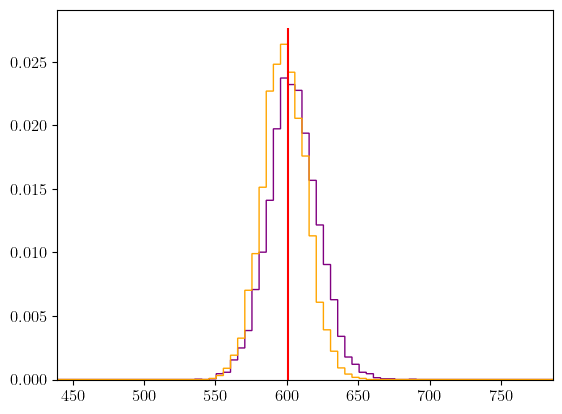

In [22]:
mx = 1.3

l14_gw = np.array([np.interp(mx, posterior_gw["masses_EOS"][j], posterior_gw["lambdas_EOS"][j]) for j in range(7000)])
l14_mm = np.array([np.interp(mx, posterior_mm["masses_EOS"][j], posterior_mm["lambdas_EOS"][j]) for j in range(7000)])


bins = np.linspace(0, 5000, 1000)
plt.hist(l14_gw, color="purple", density=True, histtype="step", bins=bins)
plt.hist(l14_mm, color="orange", density=True, histtype="step", bins=bins)

plt.vlines([np.interp(mx, m_eos, l_eos)], *plt.gca().get_ylim(), color="red")
plt.xlim((l14_mm.min()*0.8, l14_mm.max()*1.2))

(10.0, 13.0)

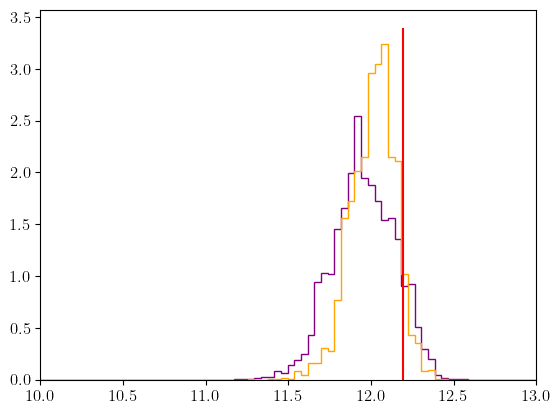

In [26]:
m_x = 1.2

r14_gw = np.array([np.interp(m_x, posterior_gw["masses_EOS"][j], posterior_gw["radii_EOS"][j]) for j in range(7000)])
r14_mm = np.array([np.interp(m_x, posterior_mm["masses_EOS"][j], posterior_mm["radii_EOS"][j]) for j in range(7000)])


bins = np.linspace(10, 14, 100)
plt.hist(r14_gw, color="purple", density=True, histtype="step", bins=bins, weights=posterior_gw["weights"])
plt.hist(r14_mm, color="orange", density=True, histtype="step", bins=bins, weights=posterior_mm["weights"])

plt.vlines([np.interp(m_x, m_eos, r_eos)], *plt.gca().get_ylim(), color="red")

plt.xlim(10, 13.0)

# compare all posteriors


In [9]:
wide_ETL_gw = load_posterior(Path("../wide_ETL") / "eos_inference_gw" / "outdir" / "results.h5")
wide_ETT_gw = load_posterior(Path("../wide_ETT") / "eos_inference_gw" / "outdir" / "results.h5")
narrow_ETL_gw = load_posterior(Path("../narrow_ETL") / "eos_inference_gw" / "outdir" / "results.h5")
narrow_ETT_gw = load_posterior(Path("../narrow_ETT") / "eos_inference_gw" / "outdir" / "results.h5")

wide_ETL_mm = load_posterior(Path("../wide_ETL") / "eos_inference_mm" / "outdir" / "results.h5")
wide_ETT_mm = load_posterior(Path("../wide_ETT") / "eos_inference_mm" / "outdir" / "results.h5")
narrow_ETL_mm = load_posterior(Path("../narrow_ETL") / "eos_inference_mm" / "outdir" / "results.h5")
narrow_ETT_mm = load_posterior(Path("../narrow_ETT") / "eos_inference_mm" / "outdir" / "results.h5")




## make table

In [10]:
with open("table.tex", "w")as out:
    out.write("\\midrule \n")

    #L14

    line = "\\SetCell[r=2]{c} $\\Lambda_{1.4}$ &"
    for posterior in [narrow_ETL_gw, wide_ETL_gw, narrow_ETT_gw, wide_ETT_gw]:
        line += f" ${l14_confidence_interval(posterior)}$ &"
    line += f"\\SetCell[r=2]{{c}} {np.interp(1.4, m_eos, l_eos):.0f} \\\\ \n"
    out.write(line)

    line = " &"
    for posterior in [narrow_ETL_mm, wide_ETL_mm, narrow_ETT_mm, wide_ETT_mm]:
        line += f" $({l14_confidence_interval(posterior)})$ &"
    line += "\\\\[0.5em] \n"
    out.write(line)

    #R14

    line = "\\SetCell[r=2]{c} $R_{1.4}$ \\newline [km] &"
    for posterior in [narrow_ETL_gw, wide_ETL_gw, narrow_ETT_gw, wide_ETT_gw]:
        line += f" ${r14_confidence_interval(posterior)}$ &"
    line += f"\\SetCell[r=2]{{c}} {np.interp(1.4, m_eos, r_eos):.2f} \\\\ \n"
    out.write(line)

    line = " &"
    for posterior in [narrow_ETL_mm, wide_ETL_mm, narrow_ETT_mm, wide_ETT_mm]:
        line += f" $({r14_confidence_interval(posterior)})$ &"
    line += "\\\\[0.5em] \n"
    out.write(line)

    # MTOV

    line = "\\SetCell[r=2]{c} $M_{\\rm{TOV}}$ \\newline $[\\msun]$ &"
    for posterior in [narrow_ETL_gw, wide_ETL_gw, narrow_ETT_gw, wide_ETT_gw]:
        line += f" ${mtov_confidence_interval(posterior)}$ &"
    line += f"\\SetCell[r=2]{{c}} {m_eos.max():.2f} \\\\ \n"
    out.write(line)

    line = " &"
    for posterior in [narrow_ETL_mm, wide_ETL_mm, narrow_ETT_mm, wide_ETT_mm]:
        line += f" $({mtov_confidence_interval(posterior)})$ &"
    line += "\\\\[0.5em] \n"
    out.write(line)



    # p3snat

    line = "\\SetCell[r=2]{c} $p(3\\nsat)$ [MeV~fm$^{{-3}}$] &"
    for posterior in [narrow_ETL_gw, wide_ETL_gw, narrow_ETT_gw, wide_ETT_gw]:
        line += f" ${pressure_confidence_interval(posterior)}$ &"
    line += f"\\SetCell[r=2]{{c}} {np.interp(3, n_eos/0.16, p_eos):.0f} \\\\ \n"
    out.write(line)

    line = " &"
    for posterior in [narrow_ETL_mm, wide_ETL_mm, narrow_ETT_mm, wide_ETT_mm]:
        line += f" $({pressure_confidence_interval(posterior)})$ &"
    line += "\\\\[0.5em] \n"
    out.write(line)


    out.write("\\midrule \n")

    # mu_1
    key = "mu_1"
    line = f"\\SetCell[r=2]{{c}} $\\mu_1~[\\msun]$ & ${confidence_interval(narrow_ETL_gw, key)}$ & - & ${confidence_interval(narrow_ETT_gw, key)}$ & - & \\SetCell[r=2]{{c}} 1.34 \\\\ \n" 
    out.write(line)
    line = f" & $({confidence_interval(narrow_ETL_mm, key)})$ & - & $({confidence_interval(narrow_ETT_mm, key)})$ & - &  \\\\[0.5em] \n" 
    out.write(line)

    # sigma_1
    key = "sigma_1"
    line = f"\\SetCell[r=2]{{c}} $\\sigma_1~[\\msun]$ & ${confidence_interval(narrow_ETL_gw, key)}$ & - & ${confidence_interval(narrow_ETT_gw, key)}$ & - & \\SetCell[r=2]{{c}} 0.02 \\\\ \n" 
    out.write(line)
    line = f" & $({confidence_interval(narrow_ETL_mm, key)})$ & - & $({confidence_interval(narrow_ETT_mm, key)})$ & - &  \\\\[0.5em] \n" 
    out.write(line)

    # mu_2
    key = "mu_2"
    line = f"\\SetCell[r=2]{{c}} $\\mu_2~[\\msun]$ & ${confidence_interval(narrow_ETL_gw, key)}$ & - & ${confidence_interval(narrow_ETT_gw, key)}$ & - & \\SetCell[r=2]{{c}} 1.47 \\\\ \n" 
    out.write(line)
    line = f" & $({confidence_interval(narrow_ETL_mm, key)})$ & - & $({confidence_interval(narrow_ETT_mm, key)})$ & - &  \\\\[0.5em] \n" 
    out.write(line)

    # sigma_2
    key = "sigma_2"
    line = f"\\SetCell[r=2]{{c}} $\\sigma_2~[\\msun]$ & ${confidence_interval(narrow_ETL_gw, key)}$ & - & ${confidence_interval(narrow_ETT_gw, key)}$ & - & \\SetCell[r=2]{{c}} 0.15 \\\\ \n" 
    out.write(line)
    line = f" & $({confidence_interval(narrow_ETL_mm, key)})$ & - & $({confidence_interval(narrow_ETT_mm, key)})$ & - &  \\\\[0.5em] \n" 
    out.write(line)

    # alpha
    key = "alpha"
    line = f"\\SetCell[r=2]{{c}} $\\alpha$ & ${confidence_interval(narrow_ETL_gw, key)}$ & - & ${confidence_interval(narrow_ETT_gw, key)}$ & - & \\SetCell[r=2]{{c}} 0.68 \\\\ \n" 
    out.write(line)
    line = f" & $({confidence_interval(narrow_ETL_mm, key)})$ & - & $({confidence_interval(narrow_ETT_mm, key)})$ & - &  \\\\[0.5em] \n" 
    out.write(line)

    # m^l
    key = "m_min"
    line = f"\\SetCell[r=2]{{c}} $m^l~[\\msun]$ & ${confidence_interval(narrow_ETL_gw, key)}$ & - & ${confidence_interval(narrow_ETT_gw, key)}$ & - & \\SetCell[r=2]{{c}} 1.16 \\\\ \n" 
    out.write(line)
    line = f" & $({confidence_interval(narrow_ETL_mm, key)})$ & - & $({confidence_interval(narrow_ETT_mm, key)})$ & - &  \\\\[0.5em] \n" 
    out.write(line)

    # m^u
    key = "m_max"
    line = f"\\SetCell[r=2]{{c}} $m^u~[\\msun]$ & ${confidence_interval(narrow_ETL_gw, key)}$ & - & ${confidence_interval(narrow_ETT_gw, key)}$ & - & \\SetCell[r=2]{{c}} 1.42 \\\\ \n" 
    out.write(line)
    line = f" & $({confidence_interval(narrow_ETL_mm, key)})$ & - & $({confidence_interval(narrow_ETT_mm, key)})$ & - &  \\\\[0.5em] \n" 
    out.write(line)


    out.write("\\midrule \n")

    # m_min
    key = "m_min"
    line = f"\\SetCell[r=2]{{c}} $m_{{\\rm min}}$ $[\\msun]$ & - & ${confidence_interval(wide_ETL_gw, key)}$ & - & ${confidence_interval(wide_ETT_gw, key)}$ & \\SetCell[r=2]{{c}} 1.1 \\\\ \n" 
    out.write(line)
    line = f" & - & $({confidence_interval(wide_ETL_mm, key)})$ & - & $({confidence_interval(wide_ETT_mm, key)})$ &  \\\\[0.5em] \n" 
    out.write(line)

    # m_max
    key = "m_max"
    line = f"\\SetCell[r=2]{{c}} $m_{{\\rm max}}$ $[\\msun]$ & - & ${confidence_interval(wide_ETL_gw, key)}$ & - & ${confidence_interval(wide_ETT_gw, key)}$ & \\SetCell[r=2]{{c}} 2.0 \\\\ \n" 
    out.write(line)
    line = f" & - & $({confidence_interval(wide_ETL_mm, key)})$ & - & $({confidence_interval(wide_ETT_mm, key)})$ &  \\\\[0.5em] \n" 
    out.write(line)

    # alpha
    key = "alpha"
    line = f"\\SetCell[r=2]{{c}} $\\alpha$ & - & ${confidence_interval(wide_ETL_gw, key)}$ & - & ${confidence_interval(wide_ETT_gw, key)}$ & \\SetCell[r=2]{{c}} 2 \\\\ \n" 
    out.write(line)
    line = f" & - & $({confidence_interval(wide_ETL_mm, key)})$ & - & $({confidence_interval(wide_ETT_mm, key)})$ &  \\\\[0.5em] \n" 
    out.write(line)

    out.write("\\bottomrule \n")

/home/koehn1/miniconda3/envs/nmma_x_fiesta/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1601: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


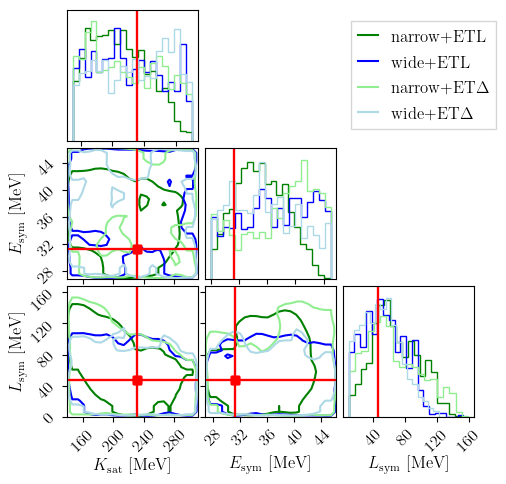

In [11]:
fig, ax = plt.subplots(3, 3, figsize=(5,5))

corner_plot(narrow_ETL_mm, parameter_names=['K_sat', 'E_sym', 'L_sym'], fig=fig, color="green", fill_contours=False, levels=[0.95])
corner_plot(wide_ETL_mm, parameter_names=['K_sat', 'E_sym', 'L_sym'], fig=fig, color="blue", fill_contours=False, levels=[0.95])
corner_plot(narrow_ETT_mm, parameter_names=['K_sat', 'E_sym', 'L_sym'], fig=fig, color="lightgreen", fill_contours=False, levels=[0.95])
corner_plot(wide_ETT_mm, parameter_names=['K_sat', 'E_sym', 'L_sym'], fig=fig, color="lightblue", fill_contours=False, levels=[0.95])

lc1 = plt.plot([], [], color="green")[0]
lc2 = plt.plot([], [], color="blue")[0]
lc3 = plt.plot([], [], color="lightgreen")[0]
lc4 = plt.plot([], [], color="lightblue")[0]
ax[0, -1].legend(
    [lc1, lc2, lc3, lc4], 
    ["narrow+ETL", "wide+ETL", "narrow+ET$\\Delta$", "wide+ET$\\Delta$"], 
    handlelength=1.2, handleheight=1.2, fontsize=12,
    loc='center left', frameon=True, fancybox=False, ncol=1
)

fig.savefig("../../figures/NEP_all.pdf", dpi=250, bbox_inches="tight")

In [13]:
confidence_interval(narrow_ETL_mm, "L_sym")

'{63.73}_{-45.12}^{+60.27}'